# Batch preview — dwa osobne ploty na sample

Ten notebook robi dla losowych sampli dwa osobne wykresy:

1. **All labels**: `certain / false / not`
   - `certain` = prawdziwy wierzchołek, czyli wcześniejsze `real`
   - `false` = fałszywy wierzchołek / crossing / overlap, czyli wcześniejsze `fake`
   - `not` = brak sensownego kandydata

2. **Only certain**: pokazuje tylko prawdziwe wierzchołki (`certain`)

Każdy wykres jest osobną figurą, nie subplotem.


In [ ]:
from pathlib import Path
from itertools import combinations
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage.morphology import (
    skeletonize,
    medial_axis,
    remove_small_objects,
    binary_closing,
    disk,
)
from skimage.measure import label, regionprops


## 1. Config

In [ ]:
DATA_ROOT = Path("raw_datasets")
USE_GROUND_TRUTH = True

N_RANDOM_SAMPLES = 10
RANDOM_SEED = 42

MIN_OBJECT_SIZE = 30
USE_MEDIAL_AXIS = True
PRUNE_MIN_ARM_LEN = 4
PRUNE_ITERATIONS = 1

JUNCTION_GROUP_DILATION = 3
MIN_JUNCTION_AREA = 1

REMOVE_RADIUS = 2
MAX_ARM_STEPS = 60
MIN_ARM_LEN = 4

ENABLE_LOCAL_RESKELETON = True
LOCAL_CROP_SIZE = 80
LOCAL_USE_MEDIAL_AXIS = True
LOCAL_REMOVE_RADIUS = 2
LOCAL_MAX_ARM_STEPS = 80
LOCAL_MIN_ARM_LEN = 2
LOCAL_KEEP_SHORT_ARMS = True
LOCAL_PRUNE_MIN_ARM_LEN = 2
LOCAL_PRUNE_ITERATIONS = 0

FAKE_MEAN_COST_THR = 0.25
FAKE_MAX_COST_THR = 0.40

ALLOW_TWO_ARM_FAKE = True
MIN_AREA_FOR_TWO_ARM_FAKE = 6

ENABLE_THICKNESS_FAKE = True
THICKNESS_RADIUS = 5
THICKNESS_FAKE_THR = 2.0
THICKNESS_AREA_THR = 4


## 2. Data loading

In [3]:
def scan_pgm_dataset(root=DATA_ROOT):
    root = Path(root)
    images = {}
    masks = {}

    for p in root.rglob("*.pgm"):
        stem = p.stem
        low = stem.lower()

        is_mask = (
            stem.endswith("_gt")
            or stem.endswith("_manual1")
            or stem.endswith("_manual")
            or "manual" in low
            or low.endswith("gt")
            or "_gt" in low
        )

        if is_mask:
            key = stem.replace("_gt", "").replace("_manual1", "").replace("_manual", "")
            masks[key] = p
        else:
            images[stem] = p

    rows = []
    for key, img_path in images.items():
        rows.append({
            "id": key,
            "image_path": img_path,
            "mask_path": masks.get(key),
            "has_mask": key in masks,
        })

    return sorted(rows, key=lambda x: str(x["image_path"]))


def read_gray(path):
    arr = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if arr is None:
        raise FileNotFoundError(f"Nie można wczytać: {path}")
    return arr


def make_fallback_mask(image):
    blur = cv2.GaussianBlur(image, (5, 5), 0)
    return cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] > 0


def load_sample_by_index(sample_index, samples, use_ground_truth=True):
    row = samples[sample_index]
    image = read_gray(row["image_path"])

    if use_ground_truth and row["mask_path"] is not None:
        raw_mask = read_gray(row["mask_path"]) > 0
    else:
        raw_mask = make_fallback_mask(image)

    return image, raw_mask, row


samples = scan_pgm_dataset(DATA_ROOT)
print("Found samples:", len(samples))
display(pd.DataFrame(samples).head(20))


Found samples: 134


,id,image_path,mask_path,has_mask
0,109,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
1,110,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
2,115,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
3,116,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
4,132,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
5,15,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
6,22,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
7,26,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
8,31,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
9,37,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True


## 3. Pipeline helpers

In [4]:
NEIGHBORS_8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def in_bounds(r, c, shape):
    return 0 <= r < shape[0] and 0 <= c < shape[1]


def clean_mask(mask, min_object_size=MIN_OBJECT_SIZE):
    m = mask.astype(bool)
    m = binary_closing(m, disk(1))
    m = remove_small_objects(m, min_size=min_object_size)
    return m


def count_neighbors(skeleton):
    sk = skeleton.astype(np.uint8)
    kernel = np.array([
        [1, 1, 1],
        [1, 0, 1],
        [1, 1, 1],
    ], dtype=np.uint8)
    return ndi.convolve(sk, kernel, mode="constant", cval=0)


def endpoint_mask(skeleton):
    return (skeleton > 0) & (count_neighbors(skeleton) == 1)


def junction_pixel_mask(skeleton, min_neighbors=3):
    return (skeleton > 0) & (count_neighbors(skeleton) >= min_neighbors)


def trace_from_endpoint(skeleton, start, max_steps=100):
    path = [start]
    prev = None
    curr = start
    shape = skeleton.shape

    for _ in range(max_steps):
        r, c = curr
        candidates = []

        for dr, dc in NEIGHBORS_8:
            nr, nc = r + dr, c + dc
            if not in_bounds(nr, nc, shape):
                continue
            if skeleton[nr, nc] == 0:
                continue
            if prev is not None and (nr, nc) == prev:
                continue
            candidates.append((nr, nc))

        if len(candidates) != 1:
            break

        prev, curr = curr, candidates[0]
        path.append(curr)

    return np.array(path)


def prune_short_spurs(skeleton, min_len=PRUNE_MIN_ARM_LEN, iterations=PRUNE_ITERATIONS):
    sk = skeleton.astype(bool).copy()

    for _ in range(iterations):
        endpoints = np.argwhere(endpoint_mask(sk))
        to_remove = []

        for r, c in endpoints:
            path = trace_from_endpoint(sk, (int(r), int(c)), max_steps=min_len + 2)
            if len(path) <= min_len:
                to_remove.extend([tuple(p) for p in path[:-1]])

        for r, c in to_remove:
            sk[r, c] = False

    return sk


def make_skeleton(mask, use_medial_axis=True):
    if use_medial_axis:
        sk, dist = medial_axis(mask.astype(bool), return_distance=True)
        return sk.astype(bool), dist
    sk = skeletonize(mask.astype(bool)).astype(bool)
    dist = ndi.distance_transform_edt(mask.astype(bool))
    return sk, dist


def group_junction_pixels(
    skeleton,
    min_neighbors=3,
    dilation_radius=JUNCTION_GROUP_DILATION,
    min_area=MIN_JUNCTION_AREA,
):
    jmask = junction_pixel_mask(skeleton, min_neighbors=min_neighbors)

    if dilation_radius > 0:
        structure = ndi.generate_binary_structure(2, 2)
        grouped = ndi.binary_dilation(jmask, structure=structure, iterations=dilation_radius)
    else:
        grouped = jmask

    lab = label(grouped, connectivity=2)

    groups = []
    for idx, reg in enumerate(regionprops(lab)):
        if reg.area < min_area:
            continue

        coords = reg.coords
        center = coords.mean(axis=0)

        groups.append({
            "id": idx,
            "center": center,
            "pixels": coords,
            "area": int(reg.area),
        })

    return groups, jmask


## 4. Arm extraction + local fallback

In [5]:
def trace_arm(skeleton, start, stop_junction_mask, max_steps=40):
    shape = skeleton.shape
    path = [start]
    prev = None
    curr = start

    for _ in range(max_steps):
        r, c = curr
        candidates = []

        for dr, dc in NEIGHBORS_8:
            nr, nc = r + dr, c + dc
            if not in_bounds(nr, nc, shape):
                continue
            if skeleton[nr, nc] == 0:
                continue
            if prev is not None and (nr, nc) == prev:
                continue
            candidates.append((nr, nc))

        if len(candidates) == 0:
            break

        non_junction = [p for p in candidates if not stop_junction_mask[p[0], p[1]]]
        if len(non_junction) == 0:
            break

        if prev is None or len(non_junction) == 1:
            nxt = non_junction[0]
        else:
            v_prev = np.array(curr) - np.array(prev)
            best_p = None
            best_score = None

            for p in non_junction:
                v_next = np.array(p) - np.array(curr)
                score = -np.dot(v_prev, v_next) / (
                    np.linalg.norm(v_prev) * np.linalg.norm(v_next) + 1e-6
                )
                if best_score is None or score < best_score:
                    best_score = score
                    best_p = p
            nxt = best_p

        prev = curr
        curr = nxt
        path.append(curr)

    return np.array(path)


def make_circular_mask(shape, center, radius):
    rr, cc = np.ogrid[:shape[0], :shape[1]]
    cy, cx = center
    return np.sqrt((rr - cy) ** 2 + (cc - cx) ** 2) <= radius


def label_border_components(skeleton, removed_region_mask):
    sk_cut = skeleton.astype(bool).copy()
    sk_cut[removed_region_mask] = False

    dilated = ndi.binary_dilation(
        removed_region_mask,
        structure=ndi.generate_binary_structure(2, 2),
        iterations=1,
    )

    border = dilated & (~removed_region_mask) & sk_cut
    lab = label(border, connectivity=2)

    starts = []
    coords = np.argwhere(removed_region_mask)
    center = coords.mean(axis=0) if len(coords) else np.array([0, 0])

    for reg in regionprops(lab):
        pts = reg.coords
        d = np.linalg.norm(pts - center[None, :], axis=1)
        starts.append(tuple(map(int, pts[np.argmin(d)])))

    return starts, sk_cut


def extract_arms_from_removed_region(
    skeleton,
    removed_region_mask,
    all_junction_pixel_mask,
    max_arm_steps=MAX_ARM_STEPS,
    min_arm_len=MIN_ARM_LEN,
    keep_short_arms=False,
):
    starts, sk_cut = label_border_components(skeleton, removed_region_mask)

    stop_mask = all_junction_pixel_mask.copy()
    stop_mask[removed_region_mask] = False

    arms = []
    for start in starts:
        path = trace_arm(
            skeleton=sk_cut,
            start=start,
            stop_junction_mask=stop_mask,
            max_steps=max_arm_steps,
        )

        if len(path) < min_arm_len:
            if keep_short_arms and len(path) >= 2:
                arms.append({
                    "start": start,
                    "path": path,
                    "length": int(len(path)),
                    "short": True,
                })
            continue

        arms.append({
            "start": start,
            "path": path,
            "length": int(len(path)),
            "short": False,
        })

    return arms


def extract_arms_for_group(
    skeleton,
    group,
    all_junction_pixel_mask,
    remove_radius=REMOVE_RADIUS,
    max_arm_steps=MAX_ARM_STEPS,
    min_arm_len=MIN_ARM_LEN,
    keep_short_arms=False,
):
    removed = make_circular_mask(skeleton.shape, group["center"], remove_radius)
    return extract_arms_from_removed_region(
        skeleton=skeleton,
        removed_region_mask=removed,
        all_junction_pixel_mask=all_junction_pixel_mask,
        max_arm_steps=max_arm_steps,
        min_arm_len=min_arm_len,
        keep_short_arms=keep_short_arms,
    )


def crop_bounds(center, shape, size):
    cy, cx = center
    cy, cx = int(round(cy)), int(round(cx))
    half = size // 2

    y1 = max(0, cy - half)
    y2 = min(shape[0], cy + half)
    x1 = max(0, cx - half)
    x2 = min(shape[1], cx + half)

    return y1, y2, x1, x2


def local_reskeletonize_group(global_mask, group):
    y1, y2, x1, x2 = crop_bounds(group["center"], global_mask.shape, LOCAL_CROP_SIZE)

    local_mask = global_mask[y1:y2, x1:x2].copy()
    local_mask = binary_closing(local_mask, disk(1))
    local_mask = remove_small_objects(local_mask.astype(bool), min_size=max(5, MIN_OBJECT_SIZE // 3))

    local_skeleton, local_dist = make_skeleton(local_mask, use_medial_axis=LOCAL_USE_MEDIAL_AXIS)

    if LOCAL_PRUNE_ITERATIONS > 0:
        local_skeleton = prune_short_spurs(
            local_skeleton,
            min_len=LOCAL_PRUNE_MIN_ARM_LEN,
            iterations=LOCAL_PRUNE_ITERATIONS,
        )

    local_center = np.asarray(group["center"], dtype=float) - np.array([y1, x1], dtype=float)

    local_group = {
        "id": group["id"],
        "center": local_center,
        "pixels": np.array([[int(round(local_center[0])), int(round(local_center[1]))]]),
        "area": group.get("area", 1),
        "global_center": group["center"],
        "crop_offset": (y1, x1),
    }

    local_junction_mask = junction_pixel_mask(local_skeleton, min_neighbors=3)

    local_arms = extract_arms_for_group(
        skeleton=local_skeleton,
        group=local_group,
        all_junction_pixel_mask=local_junction_mask,
        remove_radius=LOCAL_REMOVE_RADIUS,
        max_arm_steps=LOCAL_MAX_ARM_STEPS,
        min_arm_len=LOCAL_MIN_ARM_LEN,
        keep_short_arms=LOCAL_KEEP_SHORT_ARMS,
    )

    global_arms = []
    for arm in local_arms:
        path = arm["path"].copy()
        path[:, 0] += y1
        path[:, 1] += x1
        global_arms.append({
            **arm,
            "path": path,
            "start": tuple(path[0]),
            "source": "local",
        })

    return {
        "local_mask": local_mask,
        "local_skeleton": local_skeleton,
        "local_dist": local_dist,
        "local_center": local_center,
        "offset": (y1, x1),
        "arms": global_arms,
    }


## 5. Classification

In [6]:
def local_thickness_score(distance_map, center, radius=THICKNESS_RADIUS):
    if distance_map is None:
        return 0.0

    cy, cx = int(round(center[0])), int(round(center[1]))
    vals = []

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy * dy + dx * dx > radius * radius:
                continue
            y, x = cy + dy, cx + dx
            if 0 <= y < distance_map.shape[0] and 0 <= x < distance_map.shape[1]:
                vals.append(float(distance_map[y, x]))

    return float(np.mean(vals)) if vals else 0.0


def max_thickness_score(distance_map, center, radius=THICKNESS_RADIUS):
    if distance_map is None:
        return 0.0

    cy, cx = int(round(center[0])), int(round(center[1]))
    vals = []

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy * dy + dx * dx > radius * radius:
                continue
            y, x = cy + dy, cx + dx
            if 0 <= y < distance_map.shape[0] and 0 <= x < distance_map.shape[1]:
                vals.append(float(distance_map[y, x]))

    return float(np.max(vals)) if vals else 0.0


def normalize_vec(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n < 1e-6:
        return v * 0
    return v / n


def arm_direction_from_center(arm, center, lookahead=12):
    path = arm["path"]
    if len(path) < 2:
        return np.array([0.0, 0.0])

    k = min(lookahead, len(path) - 1)
    p0 = np.asarray(center, dtype=float)
    p1 = np.asarray(path[k], dtype=float)
    return normalize_vec(p1 - p0)


def arm_local_curvature(arm, n_points=20):
    path = arm["path"][:n_points]
    if len(path) < 4:
        return 1.0

    dirs = []
    for i in range(1, len(path)):
        dirs.append(normalize_vec(path[i] - path[i - 1]))

    total = 0.0
    count = 0

    for i in range(1, len(dirs)):
        dot = np.clip(np.dot(dirs[i - 1], dirs[i]), -1, 1)
        total += np.arccos(dot)
        count += 1

    return float(total / max(count, 1))


def sample_intensity_along_arm(image, arm, n_points=25):
    values = []
    for r, c in arm["path"][:n_points]:
        r = int(np.clip(r, 0, image.shape[0] - 1))
        c = int(np.clip(c, 0, image.shape[1] - 1))
        values.append(float(image[r, c]))

    return np.array(values, dtype=float) if values else np.array([0.0])


def intensity_profile_similarity(image, arm_a, arm_b, n_points=25):
    ia = sample_intensity_along_arm(image, arm_a, n_points=n_points)
    ib = sample_intensity_along_arm(image, arm_b, n_points=n_points)

    m = min(len(ia), len(ib))
    if m < 3:
        return 1.0

    ia = ia[:m]
    ib = ib[:m]

    ia = (ia - ia.mean()) / (ia.std() + 1e-6)
    ib = (ib - ib.mean()) / (ib.std() + 1e-6)

    corr = np.mean(ia * ib)
    return float(1.0 - corr)


def continuation_cost(image, arm_a, arm_b, center, angle_weight=1.0, curvature_weight=0.30, intensity_weight=0.35):
    va = arm_direction_from_center(arm_a, center)
    vb = arm_direction_from_center(arm_b, center)

    dot = np.clip(np.dot(va, vb), -1, 1)
    angle_cost = (dot + 1.0) / 2.0

    curvature_cost = (arm_local_curvature(arm_a) + arm_local_curvature(arm_b)) / 2.0
    intensity_cost = intensity_profile_similarity(image, arm_a, arm_b)

    cost = (
        angle_weight * angle_cost
        + curvature_weight * curvature_cost
        + intensity_weight * intensity_cost
    )

    return float(cost)


def all_pairings(indices):
    indices = list(indices)
    if len(indices) == 0:
        yield []
        return

    first = indices[0]
    for i in range(1, len(indices)):
        second = indices[i]
        rest = indices[1:i] + indices[i + 1:]
        for pairing in all_pairings(rest):
            yield [(first, second)] + pairing


def best_pairing_cost(image, arms, center):
    n = len(arms)
    if n < 2:
        return None

    pair_costs = {}
    for i, j in combinations(range(n), 2):
        key = tuple(sorted((i, j)))
        pair_costs[key] = continuation_cost(image, arms[i], arms[j], center)

    candidate_pairings = []
    if n % 2 == 0:
        candidate_pairings = list(all_pairings(range(n)))
    else:
        for missing in range(n):
            rest = [i for i in range(n) if i != missing]
            for pairing in all_pairings(rest):
                candidate_pairings.append(pairing)

    best = None
    for pairing in candidate_pairings:
        costs = []
        for a, b in pairing:
            costs.append(pair_costs[tuple(sorted((a, b)))])
        mean_cost = float(np.mean(costs)) if costs else 999.0
        max_cost = float(np.max(costs)) if costs else 999.0

        if best is None or mean_cost < best["mean_cost"]:
            best = {"pairs": pairing, "mean_cost": mean_cost, "max_cost": max_cost}

    return best


def decide_label_from_arms(image, group, center, arms, distance_map):
    n_arms = len(arms)
    area = group.get("area", 0)

    t_mean = local_thickness_score(distance_map, center)
    t_max = max_thickness_score(distance_map, center)

    if n_arms < 3:
        if ALLOW_TWO_ARM_FAKE and n_arms == 2 and area >= MIN_AREA_FOR_TWO_ARM_FAKE:
            return "false", None, "two_arm_area_false", t_mean, t_max

        if ENABLE_THICKNESS_FAKE and n_arms <= 2:
            if area >= THICKNESS_AREA_THR and (t_mean >= THICKNESS_FAKE_THR or t_max >= THICKNESS_FAKE_THR + 1.0):
                return "false", None, "thickness_false", t_mean, t_max

        return "not", None, "too_few_arms", t_mean, t_max

    best = best_pairing_cost(image, arms, center)

    if best is None:
        return "not", None, "no_pairing", t_mean, t_max

    if (
        n_arms >= 4
        and best["mean_cost"] <= FAKE_MEAN_COST_THR
        and best["max_cost"] <= FAKE_MAX_COST_THR
    ):
        return "false", best, "good_pairing_false", t_mean, t_max

    if n_arms >= 3 and best["mean_cost"] > FAKE_MAX_COST_THR:
        return "certain", best, "bad_pairing_certain", t_mean, t_max

    if n_arms >= 4 and best["mean_cost"] <= (FAKE_MAX_COST_THR + 0.15):
        return "false", best, "soft_false", t_mean, t_max

    return "certain", best, "soft_certain", t_mean, t_max


def classify_single_junction(image, mask_clean, skeleton, group, all_junction_pixel_mask, distance_map):
    center = group["center"]

    arms = extract_arms_for_group(
        skeleton=skeleton,
        group=group,
        all_junction_pixel_mask=all_junction_pixel_mask,
        remove_radius=REMOVE_RADIUS,
        max_arm_steps=MAX_ARM_STEPS,
        min_arm_len=MIN_ARM_LEN,
        keep_short_arms=False,
    )

    label_out, best, reason, t_mean, t_max = decide_label_from_arms(
        image, group, center, arms, distance_map
    )

    used_local = False

    if ENABLE_LOCAL_RESKELETON and label_out == "not":
        local_debug = local_reskeletonize_group(mask_clean, group)
        local_arms = local_debug["arms"]

        local_label, local_best, local_reason, _, _ = decide_label_from_arms(
            image, group, center, local_arms, distance_map
        )

        if local_label != "not":
            label_out = local_label
            arms = local_arms
            best = local_best
            reason = "local_" + local_reason
            used_local = True
        elif len(local_arms) > len(arms):
            arms = local_arms
            reason = "local_more_arms_but_not"
            used_local = True

    return {
        "label": label_out,
        "reason": reason,
        "center": center,
        "group": group,
        "arms": arms,
        "n_arms": len(arms),
        "best_pairing": best,
        "thickness_mean": t_mean,
        "thickness_max": t_max,
        "used_local_reskeleton": used_local,
    }


# Pipeline for sample

In [7]:
def run_pipeline_for_sample(sample_index):
    image, raw_mask, row = load_sample_by_index(sample_index, samples, USE_GROUND_TRUTH)

    mask_clean = clean_mask(raw_mask)
    skeleton_raw, distance_map = make_skeleton(mask_clean, use_medial_axis=USE_MEDIAL_AXIS)
    skeleton_pruned = prune_short_spurs(
        skeleton_raw,
        min_len=PRUNE_MIN_ARM_LEN,
        iterations=PRUNE_ITERATIONS,
    )

    junction_groups, all_junction_pixel_mask = group_junction_pixels(skeleton_pruned)

    results = [
        classify_single_junction(
            image=image,
            mask_clean=mask_clean,
            skeleton=skeleton_pruned,
            group=g,
            all_junction_pixel_mask=all_junction_pixel_mask,
            distance_map=distance_map,
        )
        for g in junction_groups
    ]

    return {
        "image": image,
        "mask_clean": mask_clean,
        "skeleton": skeleton_pruned,
        "junction_groups": junction_groups,
        "results": results,
        "row": row,
    }


def summarize_labels(results):
    counts = {"certain": 0, "false": 0, "not": 0}
    for r in results:
        counts[r["label"]] += 1
    return counts


In [8]:
def plot_junctions(sample_out, mode="all", title_prefix=""):
    image = sample_out["image"]
    skeleton = sample_out["skeleton"]
    results = sample_out["results"]
    row = sample_out["row"]

    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap="gray")

    ys, xs = np.where(skeleton > 0)
    plt.scatter(xs, ys, s=1, c="white", alpha=0.65)

    colors = {
        "certain": "lime",
        "false": "orange",
        "not": "deepskyblue",
    }

    for idx, r in enumerate(results):
        if mode == "certain_only" and r["label"] != "certain":
            continue

        cy, cx = r["center"]
        color = colors.get(r["label"], "yellow")

        plt.scatter([cx], [cy], s=120, facecolors="none", edgecolors=color, linewidths=3)

        suffix = "L" if r.get("used_local_reskeleton") else ""
        label_text = f"{idx}:{r['label']}{suffix}"

        plt.text(cx + 3, cy - 3, label_text, color=color, fontsize=10, weight="bold")

        for arm in r["arms"]:
            path = arm["path"]
            plt.plot(path[:, 1], path[:, 0], linewidth=1.2, alpha=0.75)

    counts = summarize_labels(results)

    if mode == "all":
        title = (
            f"{title_prefix} ALL LABELS | sample={row['id']} | "
            f"certain={counts['certain']} false={counts['false']} not={counts['not']}"
        )
    else:
        title = (
            f"{title_prefix} ONLY CERTAIN | sample={row['id']} | "
            f"certain={counts['certain']}"
        )

    plt.title(title)
    plt.axis("off")
    plt.show()


## 8. Examples

Selected sample indices: [1, 16, 21, 127, 100, 103, 31, 30, 36, 76]


/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)
/tmp/ipykernel_115823/1315225399.py:162: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  local_mask = binary_closing(local_mask, disk(1))
/tmp/ipykernel_115823/1315225399.py:163: FutureWarning: Paramete

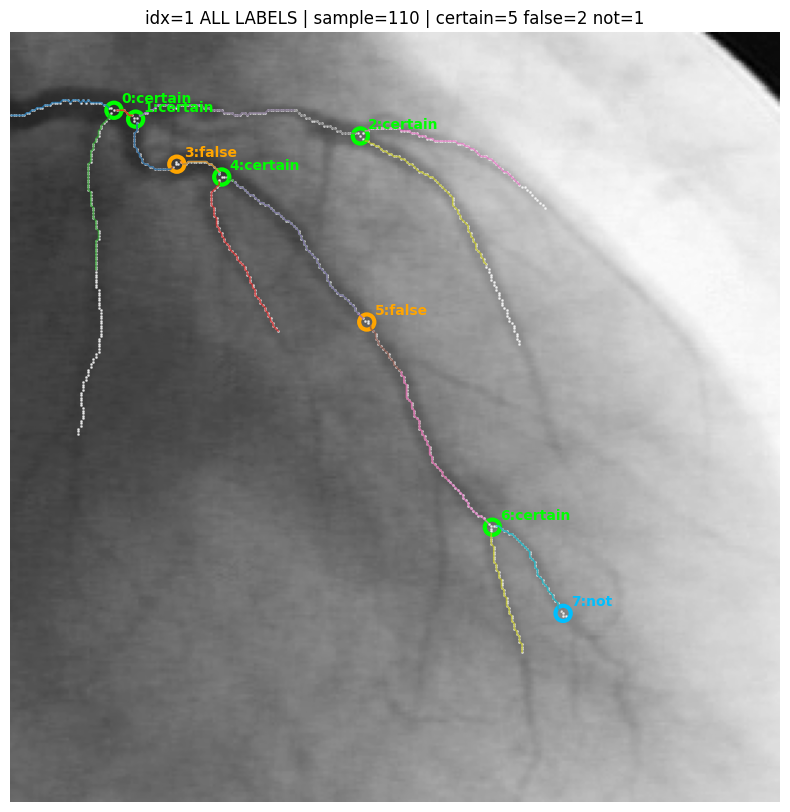

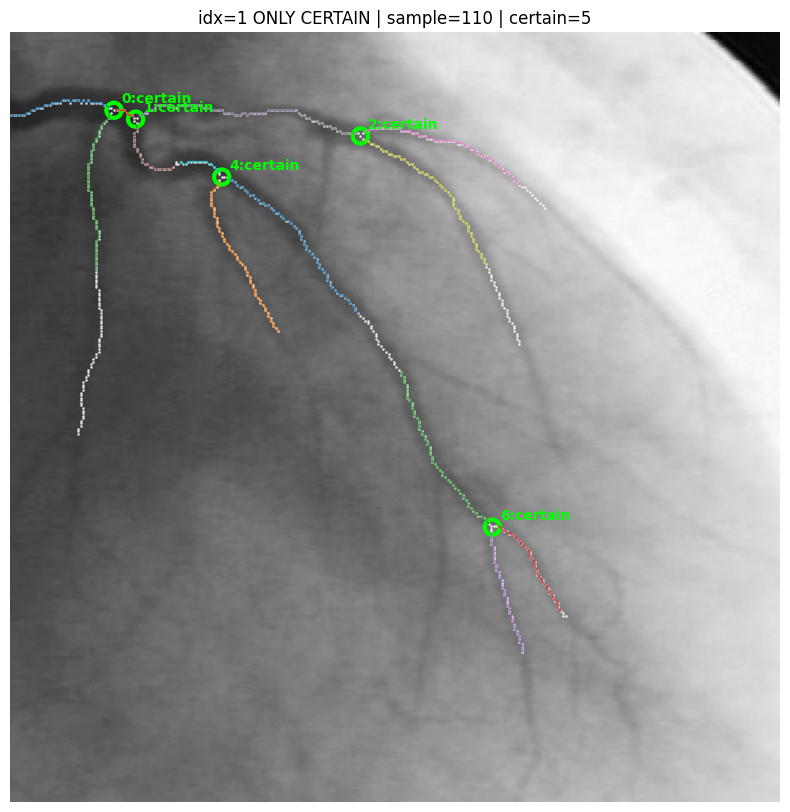

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


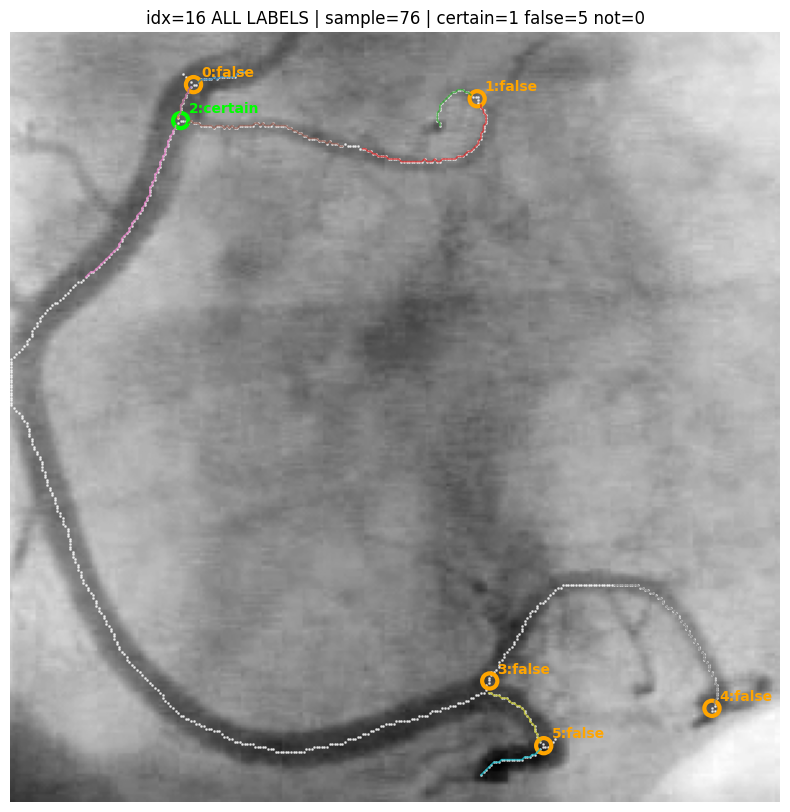

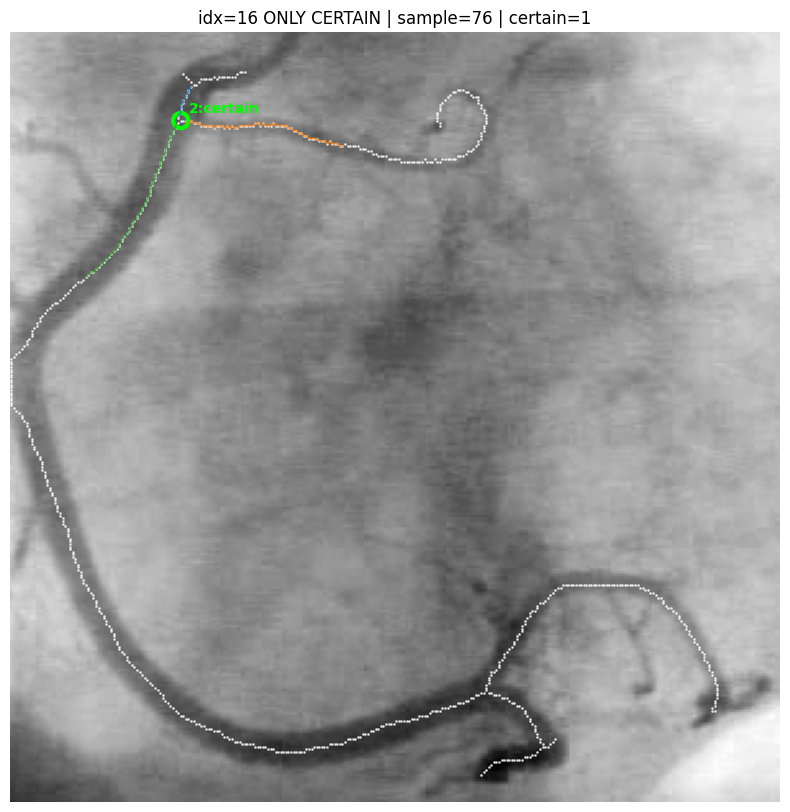

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


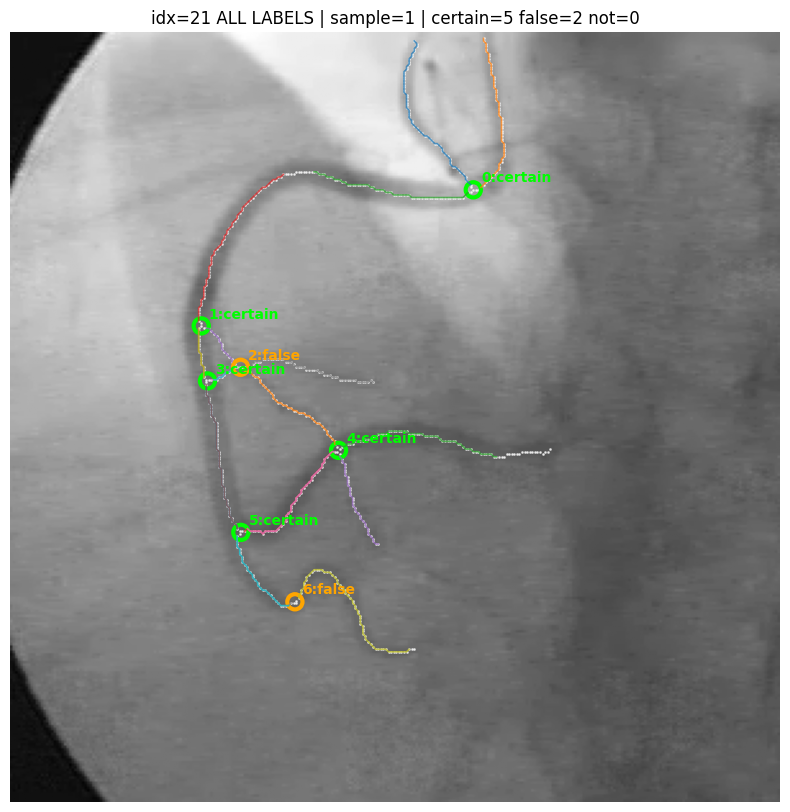

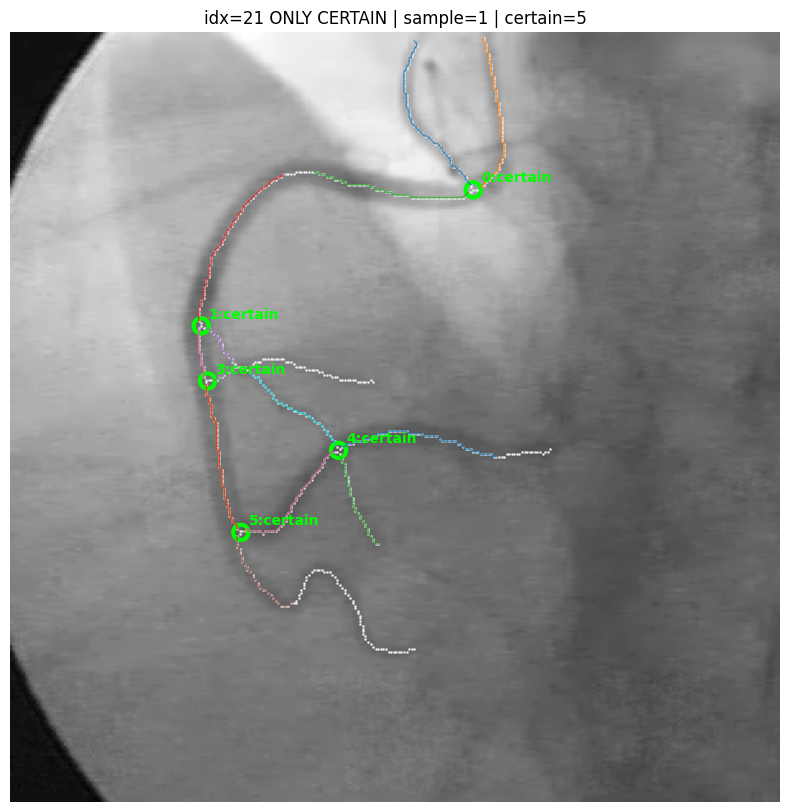

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


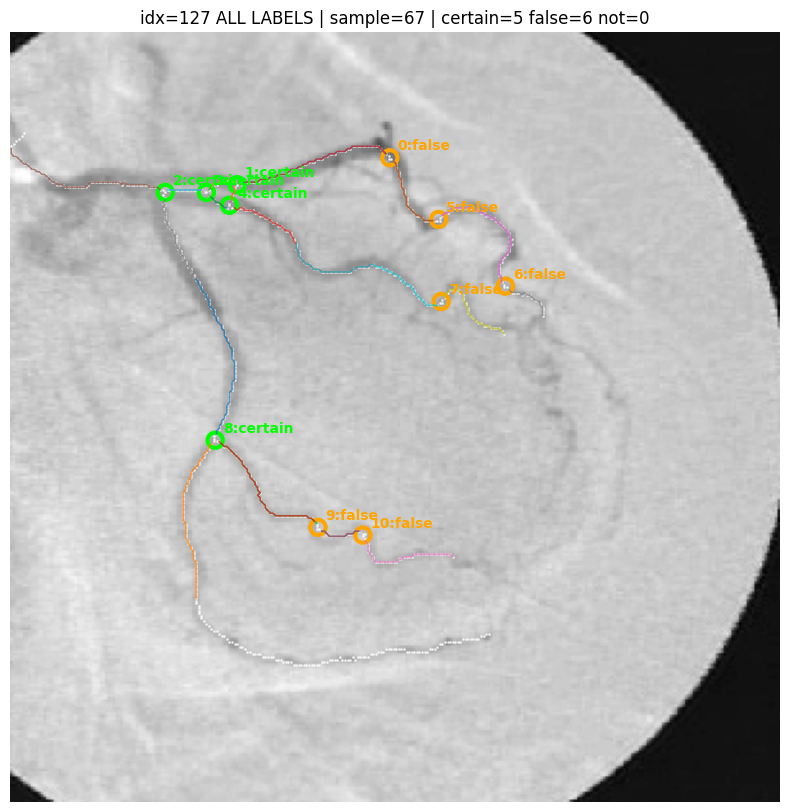

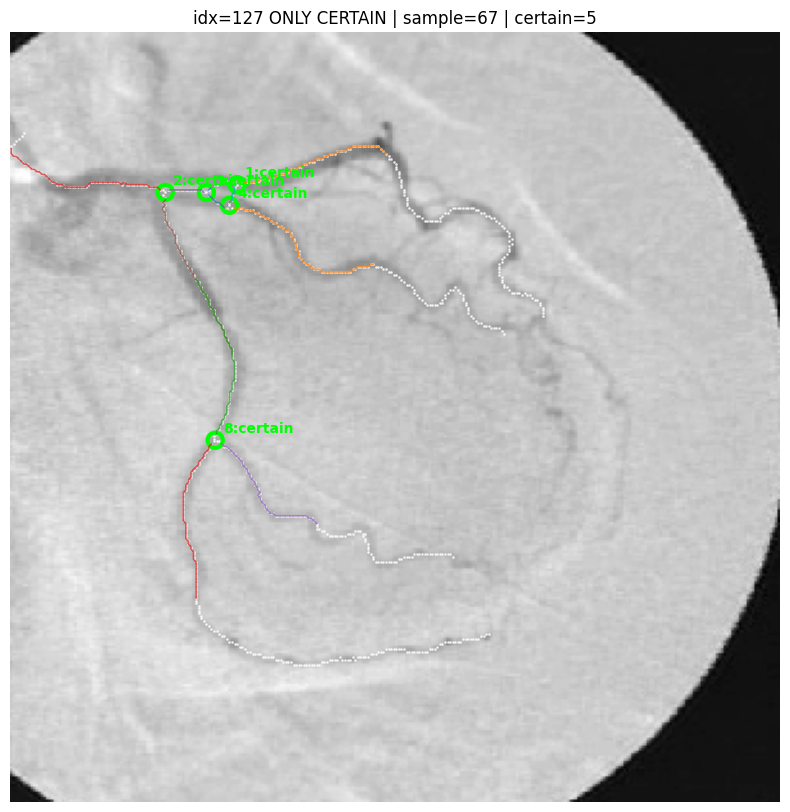

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


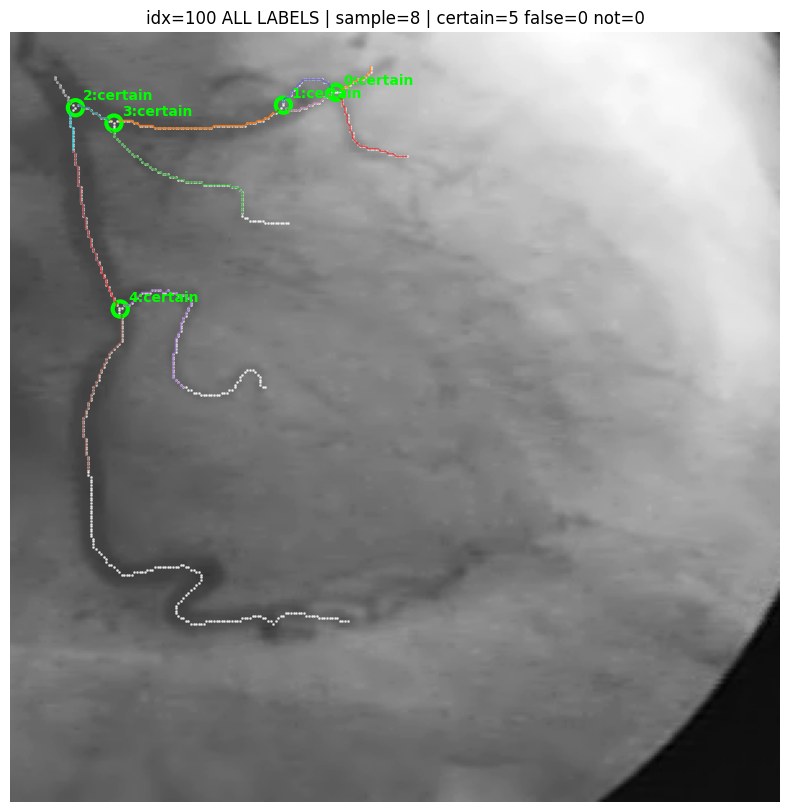

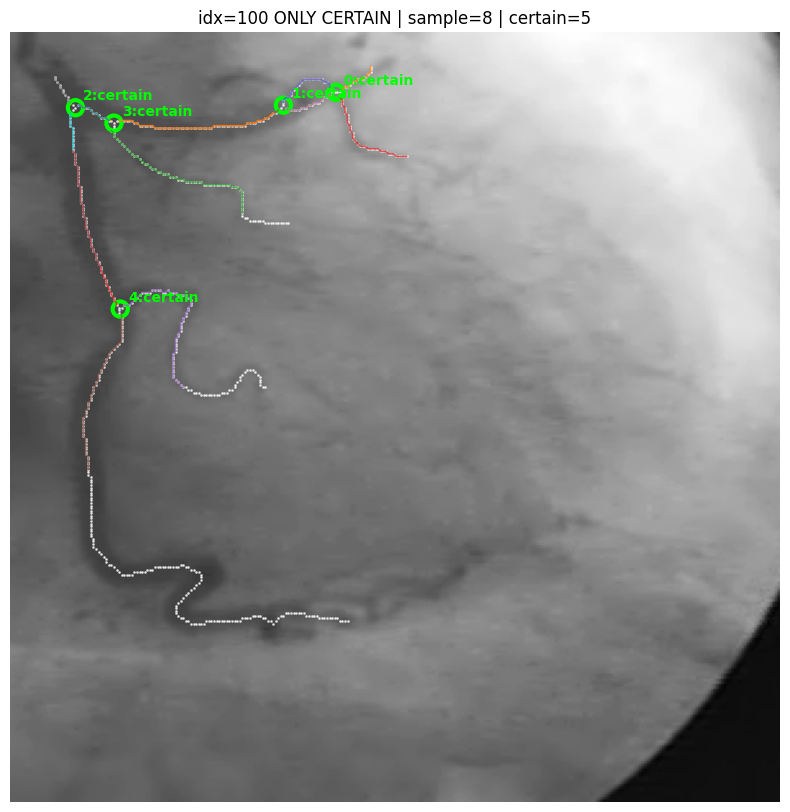

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)
/tmp/ipykernel_115823/1315225399.py:162: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  local_mask = binary_closing(local_mask, disk(1))
/tmp/ipykernel_115823/1315225399.py:163: FutureWarning: Paramete

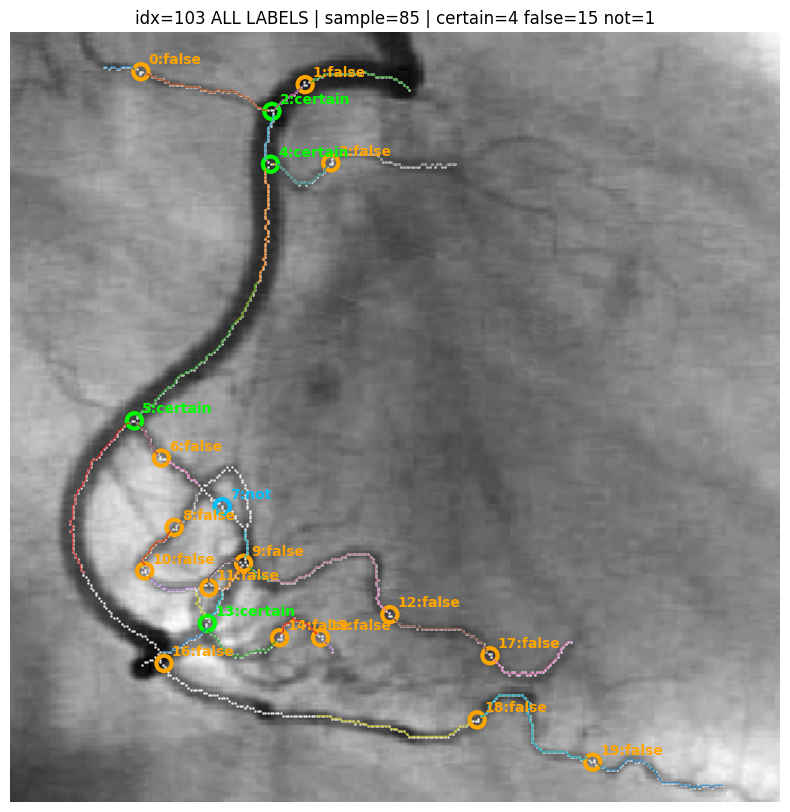

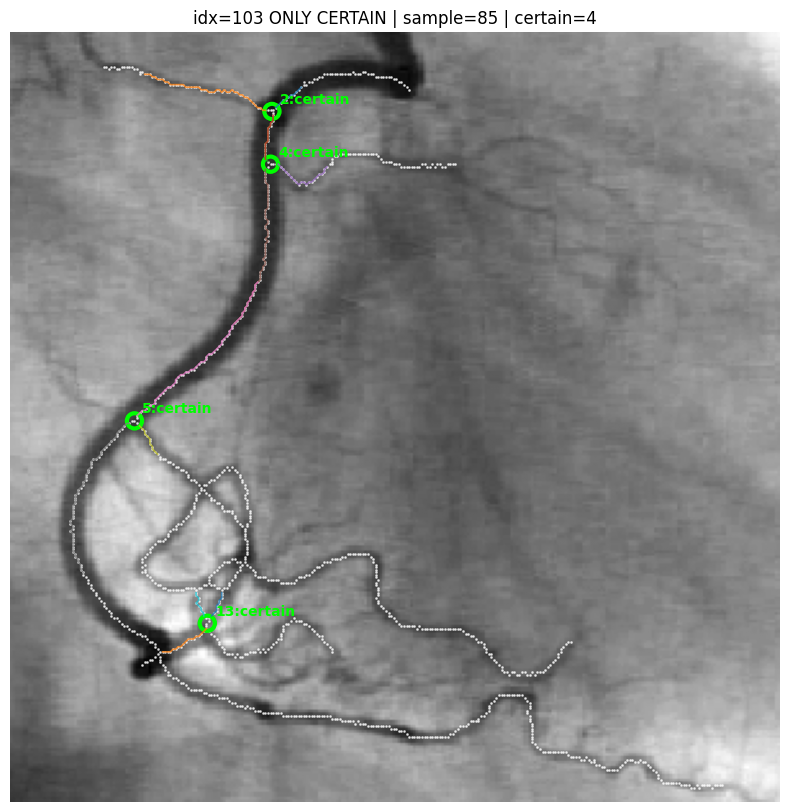

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


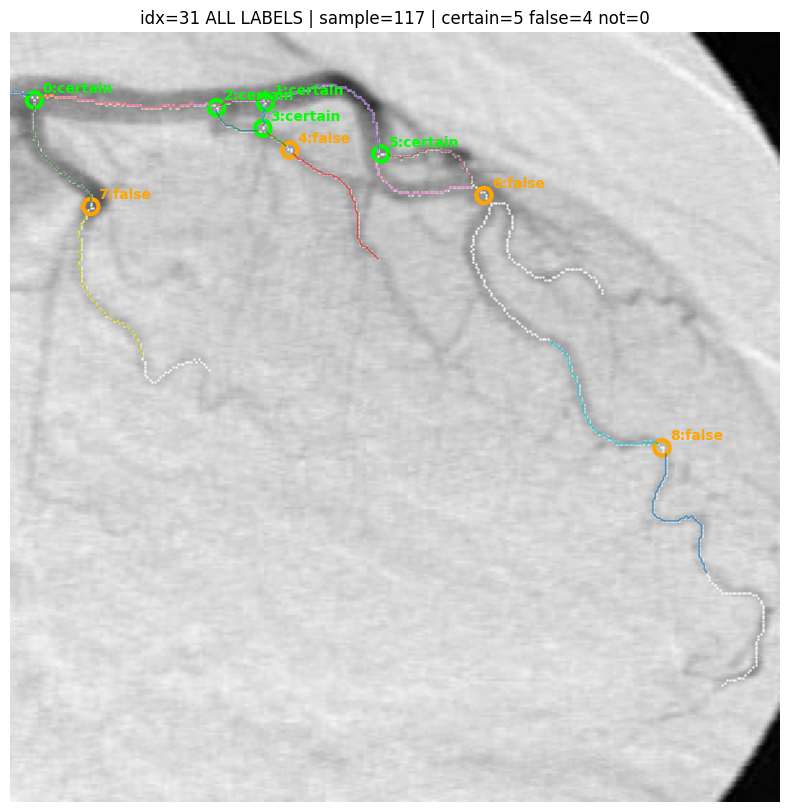

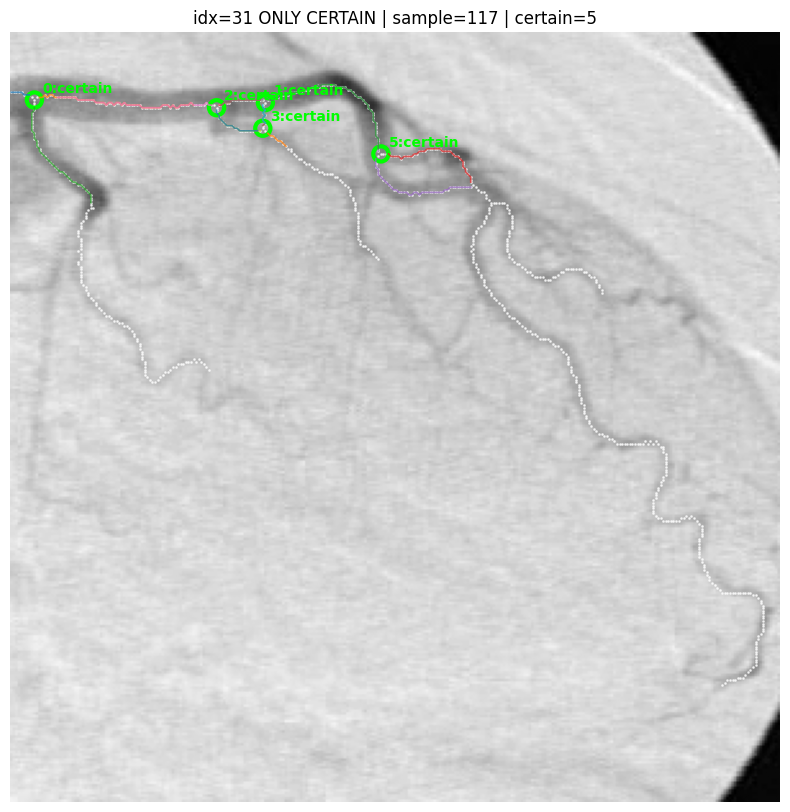

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)
/tmp/ipykernel_115823/1315225399.py:162: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  local_mask = binary_closing(local_mask, disk(1))
/tmp/ipykernel_115823/1315225399.py:163: FutureWarning: Paramete

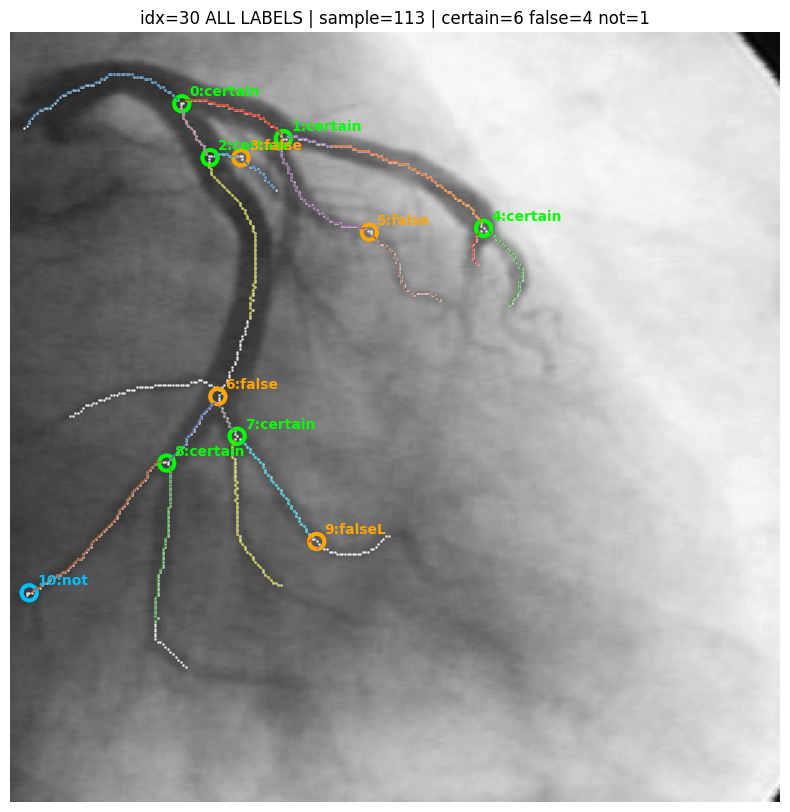

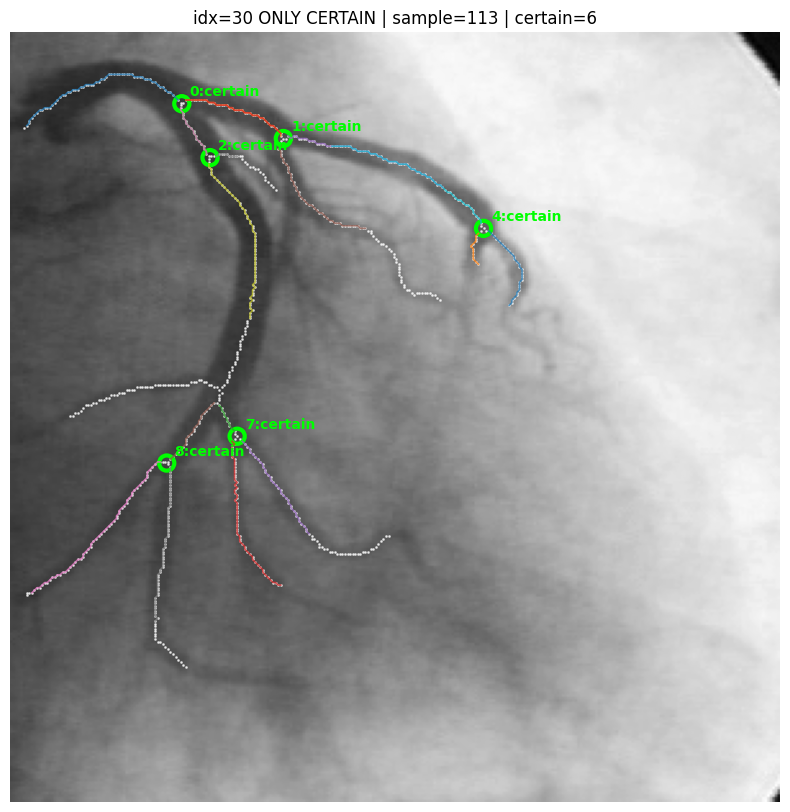

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)
/tmp/ipykernel_115823/1315225399.py:162: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  local_mask = binary_closing(local_mask, disk(1))
/tmp/ipykernel_115823/1315225399.py:163: FutureWarning: Paramete

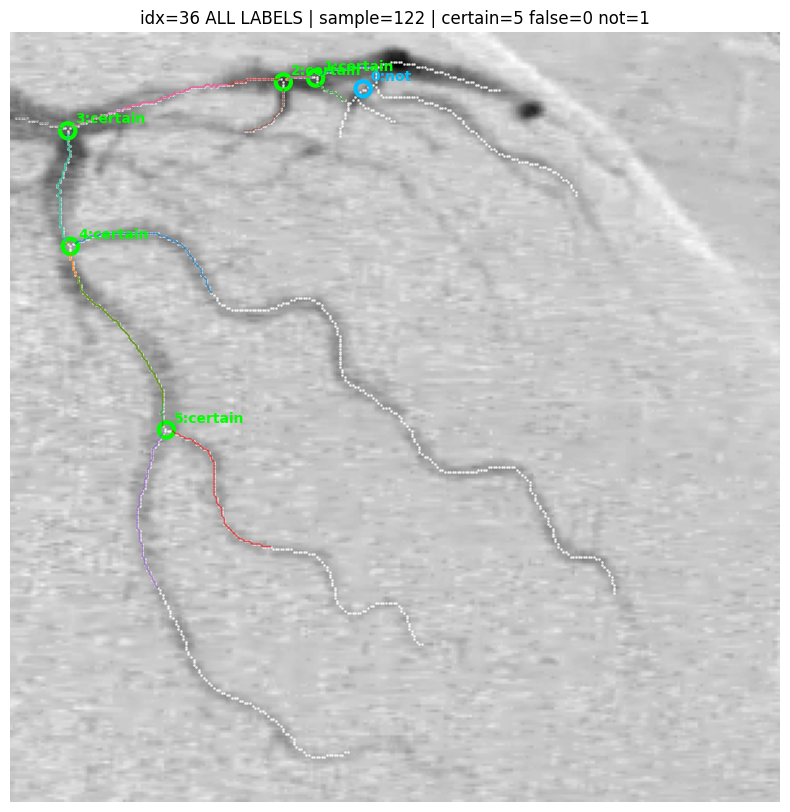

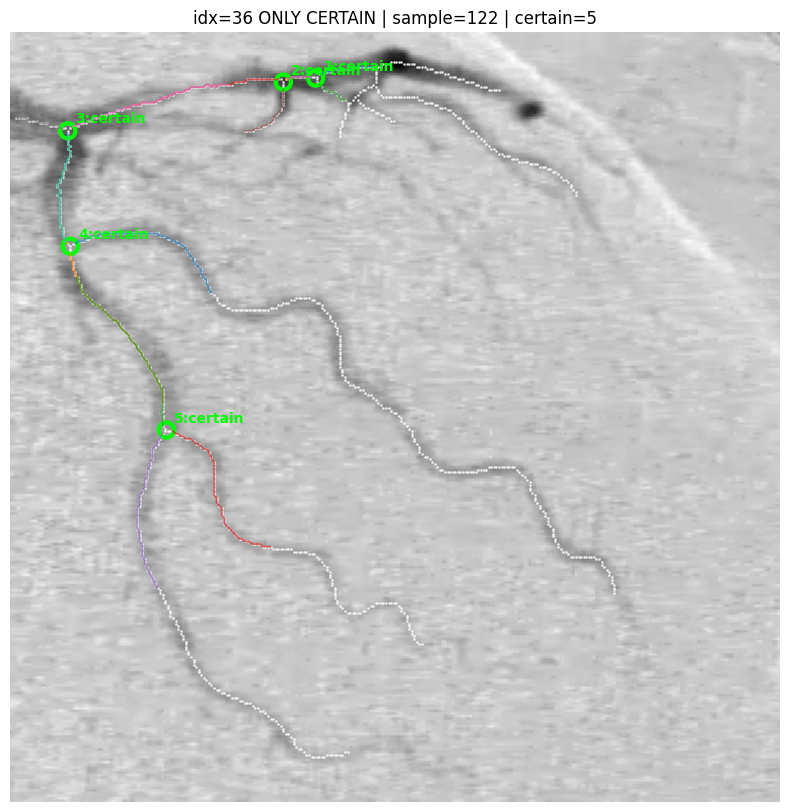

/tmp/ipykernel_115823/1919447986.py:14: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, disk(1))
/tmp/ipykernel_115823/1919447986.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_object_size)


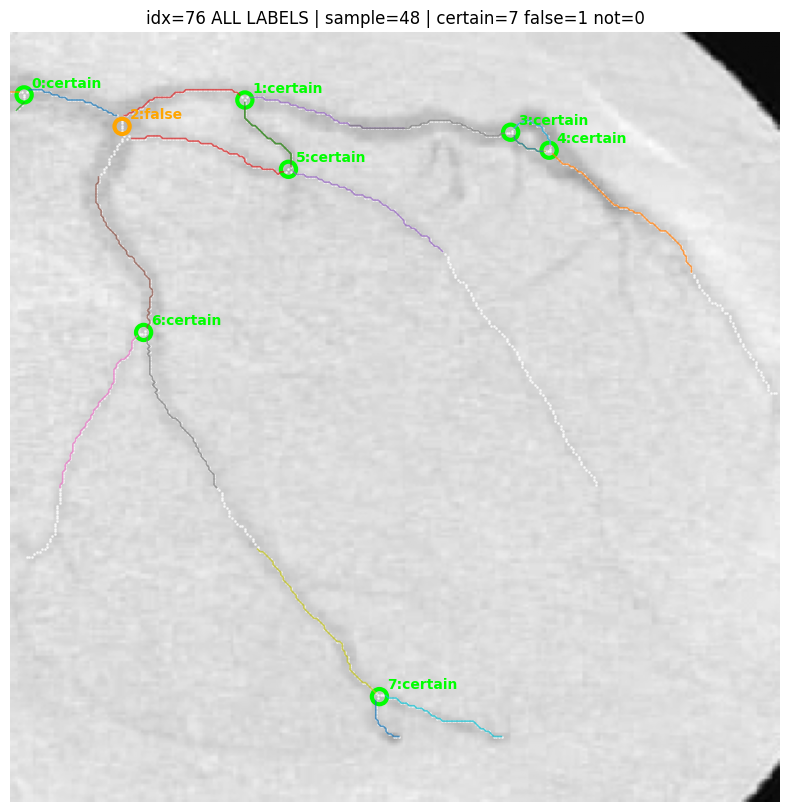

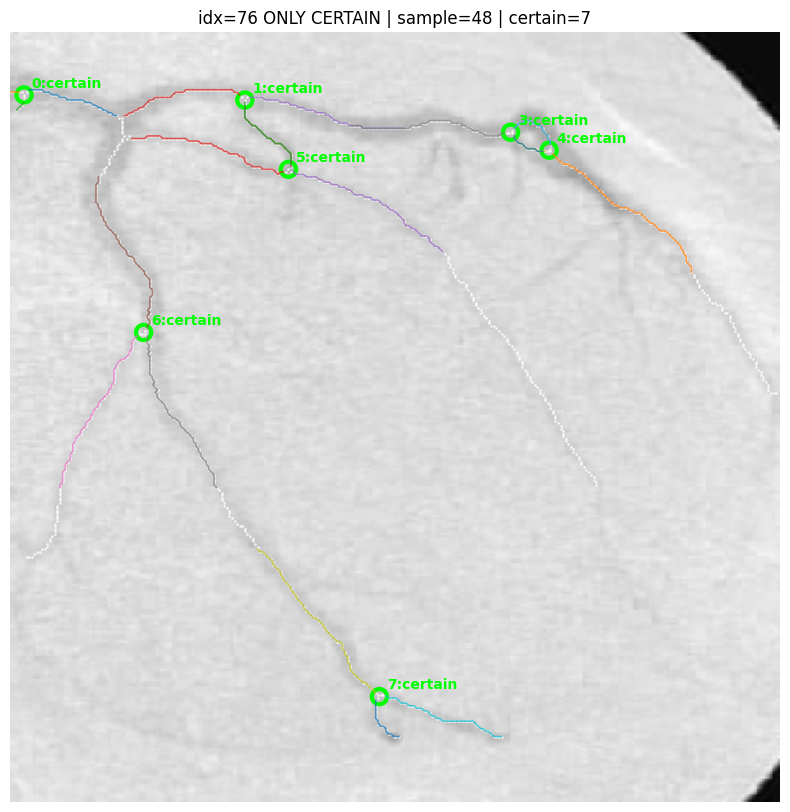

,sample_index,sample_id,certain,false,not,total
0,1,110,5,2,1,8
1,16,76,1,5,0,6
2,21,1,5,2,0,7
3,127,67,5,6,0,11
4,100,8,5,0,0,5
5,103,85,4,15,1,20
6,31,117,5,4,0,9
7,30,113,6,4,1,11
8,36,122,5,0,1,6
9,76,48,7,1,0,8


In [9]:
random.seed(RANDOM_SEED)

if len(samples) == 0:
    raise RuntimeError("Brak sampli.")

indices = list(range(len(samples)))
random.shuffle(indices)
indices = indices[:min(N_RANDOM_SAMPLES, len(indices))]

print("Selected sample indices:", indices)

batch_rows = []

for sample_idx in indices:
    out = run_pipeline_for_sample(sample_idx)
    counts = summarize_labels(out["results"])

    batch_rows.append({
        "sample_index": sample_idx,
        "sample_id": out["row"]["id"],
        "certain": counts["certain"],
        "false": counts["false"],
        "not": counts["not"],
        "total": len(out["results"]),
    })

    # Plot 1: all labels
    plot_junctions(out, mode="all", title_prefix=f"idx={sample_idx}")

    # Plot 2: only certain
    plot_junctions(out, mode="certain_only", title_prefix=f"idx={sample_idx}")

df_batch = pd.DataFrame(batch_rows)
display(df_batch)
